***Case study 5: Dự báo cổ phiểu (Phát hiện overfitting)***

• Data: 3 tập dữ liệu cổ phiếu Việt

• Xây dựng 2 mô hình RNN và LSTM với layer >=7

• Sinh viên phân tích overfit và nêu nguyên nhân, giải pháp

• Chọn mô hình tốt nhất để đưa ra dự báo theo ngày, tháng, năm

***Cell 1: Import libraries***

In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


***Cell 2: Load VCB stock dataset***

In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm

data_path = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy5\Stock_Prices_&_Volume_VN30_Index_Vietnam\VCB.csv"

df_raw = pd.read_csv(data_path)
print("Raw shape:", df_raw.shape)
display(df_raw.head())
print("Columns:", df_raw.columns.tolist())


Raw shape: (2991, 7)


,<Ticker>,<DTYYYYMMDD>,<Open>,<High>,<Low>,<Close>,<Volume>
0,VCB,20210625,110.7,112.8,108.9,112.6,1688800
1,VCB,20210624,110.0,110.8,107.8,110.7,1143400
2,VCB,20210623,108.0,111.0,107.0,109.7,2248600
3,VCB,20210622,107.1,108.5,106.5,107.6,1481900
4,VCB,20210621,106.6,108.2,106.0,106.6,2107900


Columns: ['<Ticker>', '<DTYYYYMMDD>', '<Open>', '<High>', '<Low>', '<Close>', '<Volume>']


***Cell 3: Parse date + feature engineering (multi-feature)***

In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm

date_col   = "<DTYYYYMMDD>"
open_col   = "<Open>"
high_col   = "<High>"
low_col    = "<Low>"
close_col  = "<Close>"
vol_col    = "<Volume>"

df = df_raw.copy()

# 1. Parse ngày dạng YYYYMMDD
df[date_col] = pd.to_datetime(df[date_col].astype(str), format="%Y%m%d", errors="coerce")
df = df.dropna(subset=[date_col])
df = df.sort_values(date_col).reset_index(drop=True)

# 2. Đảm bảo các cột numeric
for c in [open_col, high_col, low_col, close_col, vol_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[open_col, high_col, low_col, close_col, vol_col]).reset_index(drop=True)

# 3. Feature kỹ thuật cơ bản
df["return"] = df[close_col].pct_change().fillna(0.0)              # % thay đổi giá
df["range"]  = df[high_col] - df[low_col]                          # biên độ trong ngày
df["body"]   = df[close_col] - df[open_col]                        # thân nến
df["vol_norm"] = df[vol_col] / df[vol_col].rolling(20).mean()      # volume/MA20

# MA và volatility rolling (7 và 14 ngày)
df["ma7"]  = df[close_col].rolling(window=7).mean()
df["ma14"] = df[close_col].rolling(window=14).mean()
df["std7"] = df[close_col].rolling(window=7).std()
df["std14"] = df[close_col].rolling(window=14).std()

# Điền NaN ban đầu bằng giá trị gần nhất / trung vị
df[["ma7","ma14","std7","std14"]] = df[["ma7","ma14","std7","std14"]].fillna(method="bfill").fillna(method="ffill")
df["vol_norm"] = df["vol_norm"].fillna(1.0)

print("Shape sau khi tạo feature:", df.shape)
display(df[[date_col, close_col, "return", "range", "body", "vol_norm", "ma7", "ma14"]].head())


Shape sau khi tạo feature: (2991, 15)


C:\Users\Admin\AppData\Local\Temp\ipykernel_26376\731468305.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[["ma7","ma14","std7","std14"]] = df[["ma7","ma14","std7","std14"]].fillna(method="bfill").fillna(method="ffill")


,<DTYYYYMMDD>,<Close>,return,range,body,vol_norm,ma7,ma14
0,2009-06-30,20.9761,0.000000,0.0000,0.0000,1.0,20.226957,18.858486
1,2009-07-01,21.1509,0.008333,1.2236,-0.8740,1.0,20.226957,18.858486
2,2009-07-02,20.2769,-0.041322,0.8740,-0.5244,1.0,20.226957,18.858486
3,2009-07-03,19.5777,-0.034483,0.3496,-0.1748,1.0,20.226957,18.858486
4,2009-07-06,20.4517,0.044643,0.8740,0.8740,1.0,20.226957,18.858486


***Cell 4: Create label Up/Down + data distribution***

Data với nhãn Up/Down:


,<DTYYYYMMDD>,<Close>,change_next,up
0,2009-06-30,20.9761,0.008333,1
1,2009-07-01,21.1509,-0.041322,0
2,2009-07-02,20.2769,-0.034483,0
3,2009-07-03,19.5777,0.044643,1
4,2009-07-06,20.4517,-0.034188,0



Phân bố nhãn (Up/Down):
up
0    1655
1    1335
Name: count, dtype: int64


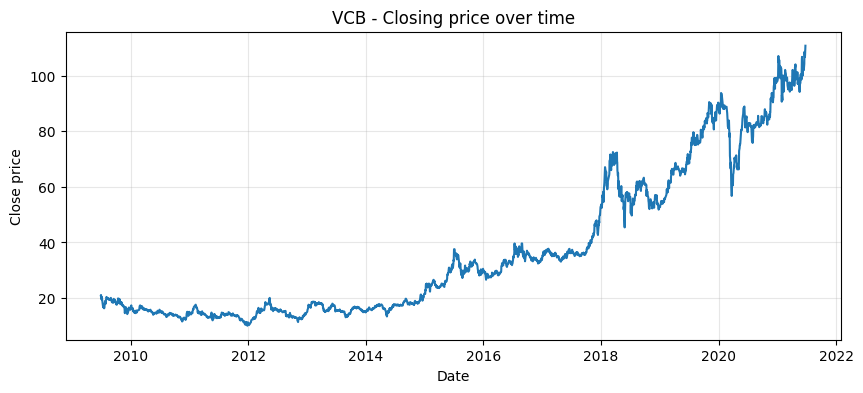

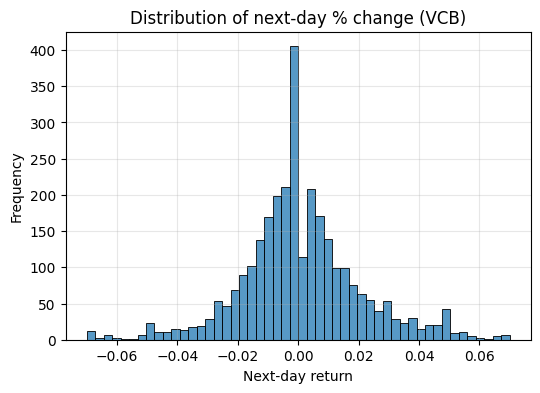

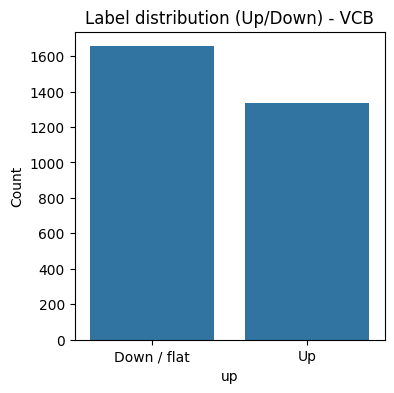

In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm

# Label: 1 nếu Close ngày mai > hôm nay + vượt ngưỡng nhỏ để tránh nhiễu
threshold = 0.001  # 0.1% để bỏ những biến động rất nhỏ
df["close_next"] = df[close_col].shift(-1)
df["change_next"] = (df["close_next"] - df[close_col]) / df[close_col]

df["up"] = (df["change_next"] > threshold).astype(int)
df = df.iloc[:-1].reset_index(drop=True)  # bỏ dòng cuối

print("Data với nhãn Up/Down:")
display(df[[date_col, close_col, "change_next", "up"]].head())

print("\nPhân bố nhãn (Up/Down):")
print(df["up"].value_counts())

# ---- Visualize: giá đóng cửa ----
plt.figure(figsize=(10,4))
plt.plot(df[date_col], df[close_col])
plt.title("VCB - Closing price over time")
plt.xlabel("Date")
plt.ylabel("Close price")
plt.grid(alpha=0.3)
plt.show()

# ---- Visualize: histogram change_next ----
plt.figure(figsize=(6,4))
sns.histplot(df["change_next"], bins=50, kde=False)
plt.title("Distribution of next-day % change (VCB)")
plt.xlabel("Next-day return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# ---- Visualize: label distribution ----
plt.figure(figsize=(4,4))
sns.countplot(x=df["up"])
plt.xticks([0,1], ["Down / flat", "Up"])
plt.title("Label distribution (Up/Down) - VCB")
plt.ylabel("Count")
plt.show()


***Cell 5: Make sequences (lookback=30) + split + scaling***

In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm

LOOKBACK = 30

feature_cols = [
    open_col, high_col, low_col, close_col, vol_col,
    "return", "range", "body", "vol_norm", "ma7", "ma14", "std7", "std14"
]
print("Sử dụng features:", feature_cols)

values = df[feature_cols].values.astype(float)
labels = df["up"].values.astype(int)
dates  = df[date_col].values

X_list, y_list, date_list = [], [], []

for i in range(len(values) - LOOKBACK + 1):
    X_list.append(values[i:i+LOOKBACK])
    y_list.append(labels[i+LOOKBACK-1])
    date_list.append(dates[i+LOOKBACK-1])

X_all = np.array(X_list)
y_all = np.array(y_list)
dates_all = np.array(date_list)

print("X_all shape:", X_all.shape)  # (N, 30, n_features)
print("y_all shape:", y_all.shape)

# Split theo thời gian: 70% train, 15% val, 15% test
n_total = len(X_all)
train_end = int(0.7 * n_total)
val_end   = int(0.85 * n_total)

X_train, y_train, dates_train = X_all[:train_end], y_all[:train_end], dates_all[:train_end]
X_val,   y_val,   dates_val   = X_all[train_end:val_end], y_all[train_end:val_end], dates_all[train_end:val_end]
X_test,  y_test,  dates_test  = X_all[val_end:], y_all[val_end:], dates_all[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)

# Scaling
n_features = X_all.shape[2]
scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, n_features)
X_val_flat   = X_val.reshape(-1, n_features)
X_test_flat  = X_test.reshape(-1, n_features)

X_train_scaled_flat = scaler.fit_transform(X_train_flat)
X_val_scaled_flat   = scaler.transform(X_val_flat)
X_test_scaled_flat  = scaler.transform(X_test_flat)

X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
X_val_scaled   = X_val_scaled_flat.reshape(X_val.shape)
X_test_scaled  = X_test_scaled_flat.reshape(X_test.shape)

print("Scaled:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

# Class weight để xử lý mất cân bằng nhãn (nếu có)
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

input_shape = (LOOKBACK, n_features)


Sử dụng features: ['<Open>', '<High>', '<Low>', '<Close>', '<Volume>', 'return', 'range', 'body', 'vol_norm', 'ma7', 'ma14', 'std7', 'std14']
X_all shape: (2961, 30, 13)
y_all shape: (2961,)
Train: (2072, 30, 13) (2072,)
Val  : (444, 30, 13) (444,)
Test : (445, 30, 13) (445,)
Scaled: (2072, 30, 13) (444, 30, 13) (445, 30, 13)
Class weights: {0: 0.8779661016949153, 1: 1.1614349775784754}


***Cell 6: Overfitting RNN model (SimpleRNN)***

In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm

def build_rnn_overfit():
    model = models.Sequential([
        layers.Input(shape=input_shape),              # 1
        layers.SimpleRNN(128, return_sequences=True), # 2
        layers.SimpleRNN(128, return_sequences=True), # 3
        layers.SimpleRNN(128, return_sequences=True), # 4
        layers.SimpleRNN(64,  return_sequences=True), # 5
        layers.SimpleRNN(64),                         # 6
        layers.Dense(64, activation="relu"),          # 7
        layers.Dense(32, activation="relu"),          # 8
        layers.Dense(1, activation="sigmoid")         # 9
    ])
    return model

rnn_model = build_rnn_overfit()
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 30, 128)             │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 30, 128)             │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 30, 128)             │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 30, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,849 (433.00 KB)

 Trainable params: 110,849 (433.00 KB)

 Non-trainable params: 0 (0.00 B)

***Cell 7: Train overfitting RNN model***

In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm

BATCH_SIZE = 32
EPOCHS_OVERFIT = 100

history_rnn = rnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS_OVERFIT,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5024 - loss: 0.7011 - val_accuracy: 0.4730 - val_loss: 0.7000
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5082 - loss: 0.6961 - val_accuracy: 0.4730 - val_loss: 0.7166
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5169 - loss: 0.6948 - val_accuracy: 0.4730 - val_loss: 0.7136
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5101 - loss: 0.6946 - val_accuracy: 0.4842 - val_loss: 0.7106
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4995 - loss: 0.7003 - val_accuracy: 0.4730 - val_loss: 0.7123
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5048 - loss: 0.6979 - val_accuracy: 0.4730 - val_loss: 0.7027
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5000 - loss: 0.6966 - val_accuracy: 0.4730 - val_loss: 0.7001
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5169 - loss: 0.6957 - val_accuracy: 0.

***Cell 8: Visualize & evaluate RNN model***

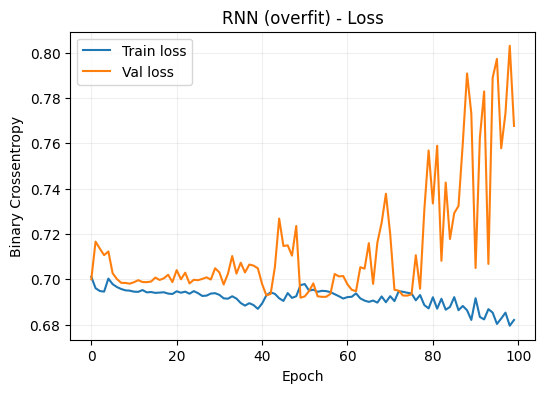

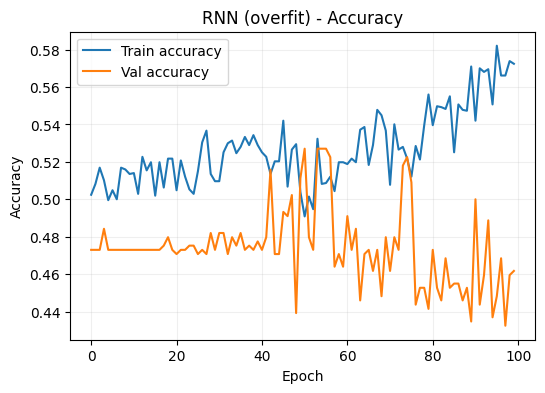

RNN Test Loss: 0.7519
RNN Test Acc : 0.4809


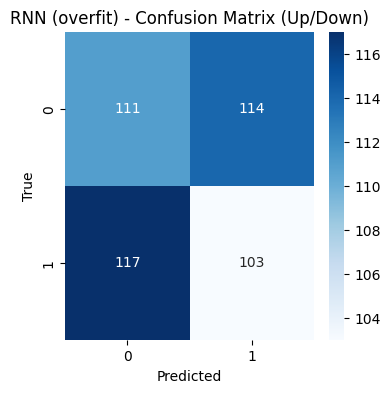

RNN (overfit) - Classification report:
              precision    recall  f1-score   support

   Down/flat       0.49      0.49      0.49       225
          Up       0.47      0.47      0.47       220

    accuracy                           0.48       445
   macro avg       0.48      0.48      0.48       445
weighted avg       0.48      0.48      0.48       445



In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm

def plot_metric(history, metric_name, title, ylabel=None):
    if ylabel is None:
        ylabel = metric_name.upper()
    plt.figure(figsize=(6,4))
    plt.plot(history.history[metric_name], label=f"Train {metric_name}")
    plt.plot(history.history[f"val_{metric_name}"], label=f"Val {metric_name}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_metric(history_rnn, "loss", "RNN (overfit) - Loss", ylabel="Binary Crossentropy")
plot_metric(history_rnn, "accuracy", "RNN (overfit) - Accuracy", ylabel="Accuracy")

# --- Evaluate ---
test_loss_rnn, test_acc_rnn = rnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"RNN Test Loss: {test_loss_rnn:.4f}")
print(f"RNN Test Acc : {test_acc_rnn:.4f}")

y_prob_rnn = rnn_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_rnn = (y_prob_rnn >= 0.5).astype(int)

cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(4,4))
sns.heatmap(cm_rnn, annot=True, fmt="d", cmap="Blues")
plt.title("RNN (overfit) - Confusion Matrix (Up/Down)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("RNN (overfit) - Classification report:")
print(classification_report(y_test, y_pred_rnn,
                            target_names=["Down/flat", "Up"], zero_division=0))


***Cell 9: Build vanilla LSTM model (likely overfitting)***

In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm

# =====================================================
# Cell 9: Build vanilla LSTM model (likely overfitting)
# =====================================================

def build_lstm_overfit():
    model = models.Sequential([
        layers.Input(shape=input_shape),             # 1
        layers.LSTM(128, return_sequences=True),     # 2
        layers.LSTM(128, return_sequences=True),     # 3
        layers.LSTM(128, return_sequences=True),     # 4
        layers.LSTM(64,  return_sequences=True),     # 5
        layers.LSTM(64),                             # 6
        layers.Dense(64, activation="relu"),         # 7
        layers.Dense(32, activation="relu"),         # 8
        layers.Dense(1, activation="sigmoid")        # 9
    ])
    return model

lstm_over_model = build_lstm_overfit()
lstm_over_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_over_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 128)             │          72,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 30, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 30, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 30, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 424,577 (1.62 MB)

 Trainable params: 424,577 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

***Cell 10: Train vanilla LSTM (overfitting)***

In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm

history_lstm_over = lstm_over_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS_OVERFIT,          # cùng số epoch với RNN để dễ so sánh
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict, # xử lý mất cân bằng nhãn
    verbose=1
)


Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.5092 - loss: 0.6947 - val_accuracy: 0.4797 - val_loss: 0.6957
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5208 - loss: 0.6942 - val_accuracy: 0.5225 - val_loss: 0.6928
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.4966 - loss: 0.6945 - val_accuracy: 0.4730 - val_loss: 0.6974
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.4865 - loss: 0.6950 - val_accuracy: 0.4730 - val_loss: 0.6968
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5290 - loss: 0.6938 - val_accuracy: 0.5270 - val_loss: 0.6929
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5246 - loss: 0.6932 - val_accuracy: 0.4730 - val_loss: 0.6943
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5405 - loss: 0.6932 - val_accuracy: 0.5270 - val_loss: 0.6930
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5357 - loss: 0.6932 - val_accuracy: 0.

***Cell 11: Visualize & evaluate vanilla LSTM***

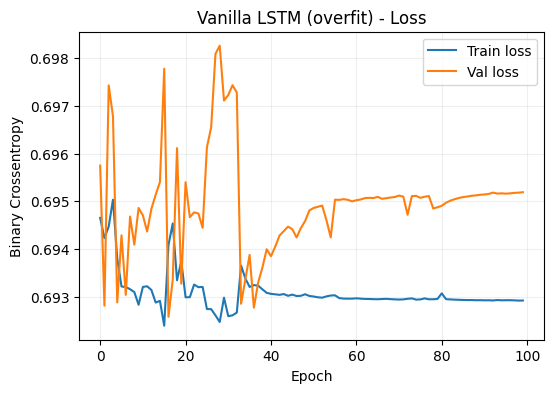

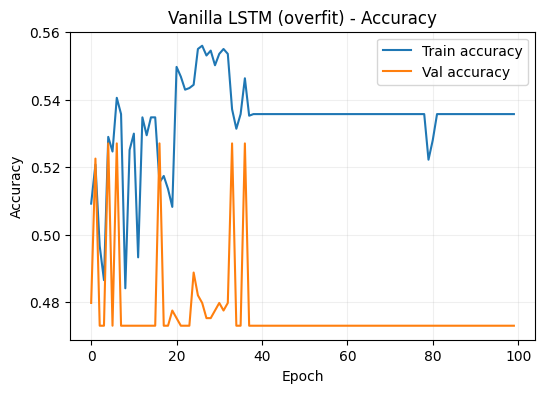

Vanilla LSTM Test Loss: 0.6939
Vanilla LSTM Test Acc : 0.4944


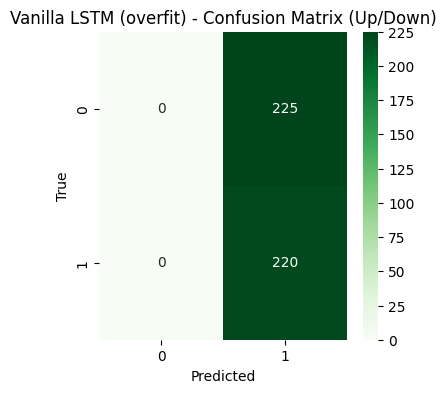

Vanilla LSTM (overfit) - Classification report:
              precision    recall  f1-score   support

   Down/flat       0.00      0.00      0.00       225
          Up       0.49      1.00      0.66       220

    accuracy                           0.49       445
   macro avg       0.25      0.50      0.33       445
weighted avg       0.24      0.49      0.33       445



In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm

# 1. Vẽ loss & accuracy
plot_metric(history_lstm_over, "loss",
            "Vanilla LSTM (overfit) - Loss", ylabel="Binary Crossentropy")
plot_metric(history_lstm_over, "accuracy",
            "Vanilla LSTM (overfit) - Accuracy", ylabel="Accuracy")

# 2. Đánh giá trên test set
test_loss_lstm_over, test_acc_lstm_over = lstm_over_model.evaluate(
    X_test_scaled, y_test, verbose=0
)
print(f"Vanilla LSTM Test Loss: {test_loss_lstm_over:.4f}")
print(f"Vanilla LSTM Test Acc : {test_acc_lstm_over:.4f}")

# 3. Confusion matrix
y_prob_lstm_over = lstm_over_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_lstm_over = (y_prob_lstm_over >= 0.5).astype(int)

cm_lstm_over = confusion_matrix(y_test, y_pred_lstm_over)

plt.figure(figsize=(4,4))
sns.heatmap(cm_lstm_over, annot=True, fmt="d", cmap="Greens")
plt.title("Vanilla LSTM (overfit) - Confusion Matrix (Up/Down)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Vanilla LSTM (overfit) - Classification report:")
print(classification_report(
    y_test, y_pred_lstm_over,
    target_names=["Down/flat", "Up"],
    zero_division=0
))


***Cell 12: Build regularized LSTM (reduce overfitting)***

In [21]:
#B22DCCN476 - Đỗ Ngọc Lâm

def build_lstm_regularized():
    reg = regularizers.l2(1e-3)
    model = models.Sequential([
        layers.Input(shape=input_shape),                                   # 1
        layers.LSTM(64, return_sequences=True,
                   kernel_regularizer=reg, recurrent_regularizer=reg),    # 2
        layers.Dropout(0.2),                                               # 3
        layers.LSTM(64, return_sequences=True,
                   kernel_regularizer=reg, recurrent_regularizer=reg),    # 4
        layers.Dropout(0.2),                                               # 5
        layers.LSTM(32,
                   kernel_regularizer=reg, recurrent_regularizer=reg),    # 6
        layers.Dense(64, activation="relu", kernel_regularizer=reg),      # 7
        layers.Dropout(0.2),                                               # 8
        layers.Dense(32, activation="relu", kernel_regularizer=reg),      # 9
        layers.Dense(1, activation="sigmoid")                             # 10
    ])
    return model

lstm_reg_model = build_lstm_regularized()
lstm_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_reg_model.summary()

# Callback giảm overfit
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)

EPOCHS_REG = 100  # epoch lớn, nhưng EarlyStopping sẽ dừng sớm


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                       │ (None, 30, 64)              │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,633 (272.00 KB)

 Trainable params: 69,633 (272.00 KB)

 Non-trainable params: 0 (0.00 B)

***Cell 13: Train regularized LSTM***

In [22]:
#B22DCCN476 - Đỗ Ngọc Lâm

history_lstm_reg = lstm_reg_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS_REG,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5154 - loss: 1.0714 - val_accuracy: 0.4730 - val_loss: 0.9981 - learning_rate: 5.0000e-04
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5039 - loss: 0.9464 - val_accuracy: 0.4730 - val_loss: 0.9014 - learning_rate: 5.0000e-04
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5043 - loss: 0.8687 - val_accuracy: 0.4730 - val_loss: 0.8409 - learning_rate: 5.0000e-04
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5101 - loss: 0.8197 - val_accuracy: 0.5225 - val_loss: 0.8025 - learning_rate: 5.0000e-04
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5063 - loss: 0.7888 - val_accuracy: 0.4640 - val_loss: 0.7775 - learning_rate: 5.0000e-04
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4947 - loss: 0.7676 - val_accuracy: 0.4685 - val_loss: 0.7596 - learning_rate: 5.0000e-04
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 

***Cell 14: Visualize & evaluate regularized LSTM***

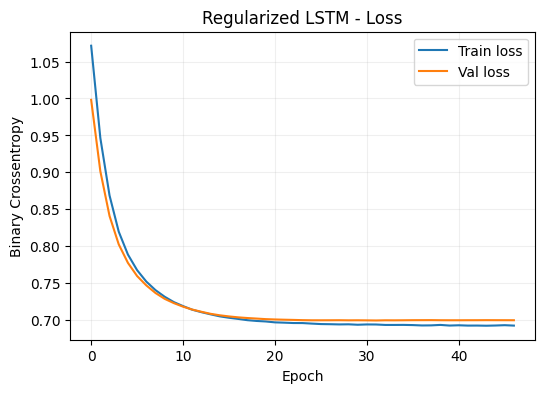

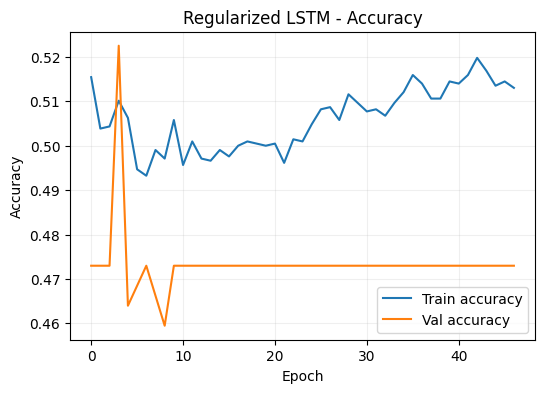

Reg-LSTM Test Loss: 0.6978
Reg-LSTM Test Acc : 0.4944


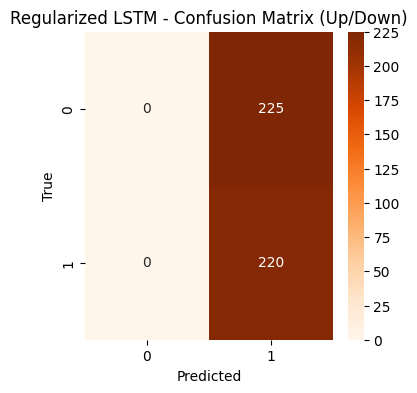

Regularized LSTM - Classification report:
              precision    recall  f1-score   support

   Down/flat       0.00      0.00      0.00       225
          Up       0.49      1.00      0.66       220

    accuracy                           0.49       445
   macro avg       0.25      0.50      0.33       445
weighted avg       0.24      0.49      0.33       445



In [23]:
#B22DCCN476 - Đỗ Ngọc Lâm

# 1. Vẽ loss & accuracy
plot_metric(history_lstm_reg, "loss",
            "Regularized LSTM - Loss", ylabel="Binary Crossentropy")
plot_metric(history_lstm_reg, "accuracy",
            "Regularized LSTM - Accuracy", ylabel="Accuracy")

# 2. Đánh giá test set
test_loss_lstm_reg, test_acc_lstm_reg = lstm_reg_model.evaluate(
    X_test_scaled, y_test, verbose=0
)
print(f"Reg-LSTM Test Loss: {test_loss_lstm_reg:.4f}")
print(f"Reg-LSTM Test Acc : {test_acc_lstm_reg:.4f}")

# 3. Confusion matrix
y_prob_lstm_reg = lstm_reg_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_lstm_reg = (y_prob_lstm_reg >= 0.5).astype(int)

cm_lstm_reg = confusion_matrix(y_test, y_pred_lstm_reg)

plt.figure(figsize=(4,4))
sns.heatmap(cm_lstm_reg, annot=True, fmt="d", cmap="Oranges")
plt.title("Regularized LSTM - Confusion Matrix (Up/Down)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Regularized LSTM - Classification report:")
print(classification_report(
    y_test, y_pred_lstm_reg,
    target_names=["Down/flat", "Up"],
    zero_division=0
))


***Cell 15: Compare RNN vs LSTM-overfit vs LSTM-regularized***

Test Accuracy:
RNN (overfit)  : 0.4809
LSTM (overfit) : 0.4944
Reg-LSTM       : 0.4944

Test Loss:
RNN (overfit)  : 0.7519
LSTM (overfit) : 0.6939
Reg-LSTM       : 0.6978


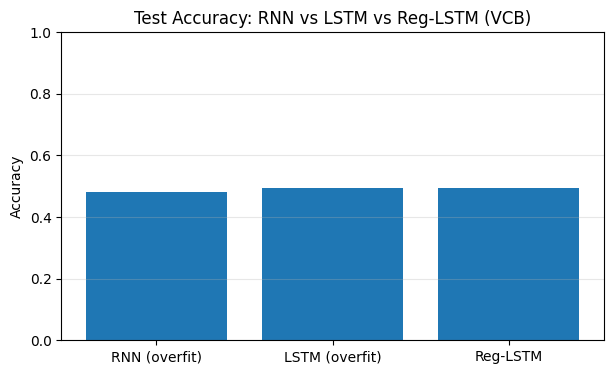

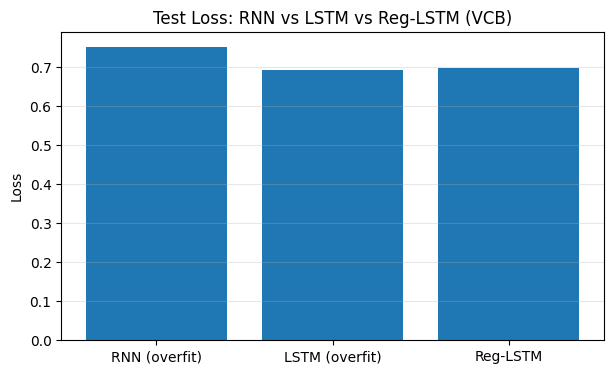


👉 Best model selected: LSTM (overfit)


In [24]:
#B22DCCN476 - Đỗ Ngọc Lâm

model_names = ["RNN (overfit)", "LSTM (overfit)", "Reg-LSTM"]
acc_values  = [test_acc_rnn, test_acc_lstm_over, test_acc_lstm_reg]
loss_values = [test_loss_rnn, test_loss_lstm_over, test_loss_lstm_reg]

print("Test Accuracy:")
for name, acc in zip(model_names, acc_values):
    print(f"{name:15s}: {acc:.4f}")

print("\nTest Loss:")
for name, loss in zip(model_names, loss_values):
    print(f"{name:15s}: {loss:.4f}")

plt.figure(figsize=(7,4))
plt.bar(model_names, acc_values)
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Test Accuracy: RNN vs LSTM vs Reg-LSTM (VCB)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(model_names, loss_values)
plt.ylabel("Loss")
plt.title("Test Loss: RNN vs LSTM vs Reg-LSTM (VCB)")
plt.grid(axis="y", alpha=0.3)
plt.show()

# chọn model tốt nhất: ưu tiên accuracy cao, nếu gần nhau thì loss thấp hơn
best_idx = int(np.argmax(acc_values))
best_model_name = model_names[best_idx]

if best_model_name.startswith("RNN"):
    best_model = rnn_model
elif "LSTM (overfit)" in best_model_name:
    best_model = lstm_over_model
else:
    best_model = lstm_reg_model

print(f"\n👉 Best model selected: {best_model_name}")


***Cell 16: Daily predictions on test set (best model)***

Một vài dòng dự báo theo ngày:


,date,y_true,y_pred,prob_up,true_label,pred_label
0,2019-09-16,1,1,0.514836,Up,Up
1,2019-09-17,0,1,0.514836,Down/flat,Up
2,2019-09-18,1,1,0.514836,Up,Up
3,2019-09-19,0,1,0.514836,Down/flat,Up
4,2019-09-20,0,1,0.514836,Down/flat,Up


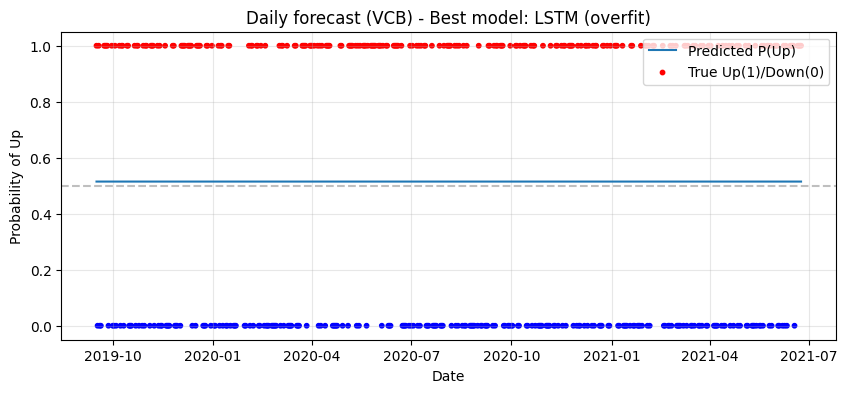

In [25]:
#B22DCCN476 - Đỗ Ngọc Lâm

y_prob_best = best_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_best = (y_prob_best >= 0.5).astype(int)

df_daily_pred = pd.DataFrame({
    "date": dates_test,
    "y_true": y_test,
    "y_pred": y_pred_best,
    "prob_up": y_prob_best
}).sort_values("date").reset_index(drop=True)

df_daily_pred["true_label"] = df_daily_pred["y_true"].map({0: "Down/flat", 1: "Up"})
df_daily_pred["pred_label"] = df_daily_pred["y_pred"].map({0: "Down/flat", 1: "Up"})

print("Một vài dòng dự báo theo ngày:")
display(df_daily_pred.head())

plt.figure(figsize=(10,4))
plt.plot(df_daily_pred["date"], df_daily_pred["prob_up"], label="Predicted P(Up)")
plt.scatter(df_daily_pred["date"], df_daily_pred["y_true"],
            s=10, c=df_daily_pred["y_true"], cmap="bwr", label="True Up(1)/Down(0)")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Probability of Up")
plt.title(f"Daily forecast (VCB) - Best model: {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


***Cell 17: Monthly forecast summary***

Tỉ lệ ngày Up theo tháng (true vs predicted):


,year_month,true_up_rate,pred_up_rate
0,2019-09-01,0.636364,1.0
1,2019-10-01,0.478261,1.0
2,2019-11-01,0.428571,1.0
3,2019-12-01,0.681818,1.0
4,2020-01-01,0.294118,1.0


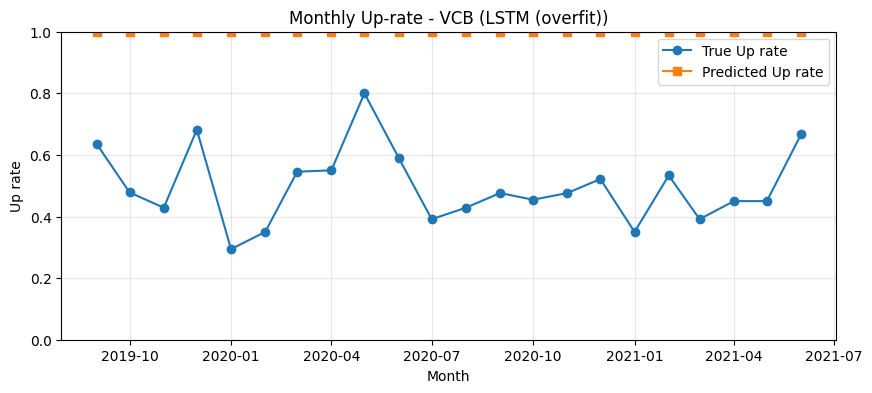

In [27]:
#B22DCCN476 - Đỗ Ngọc Lâm

df_monthly = df_daily_pred.copy()
df_monthly["date"] = pd.to_datetime(df_monthly["date"])
df_monthly["year_month"] = df_monthly["date"].dt.to_period("M").dt.to_timestamp()


monthly_summary = df_monthly.groupby("year_month").agg(
    true_up_rate = ("y_true", "mean"),
    pred_up_rate = ("y_pred", "mean")
).reset_index()

print("Tỉ lệ ngày Up theo tháng (true vs predicted):")
display(monthly_summary.head())

plt.figure(figsize=(10,4))
plt.plot(monthly_summary["year_month"], monthly_summary["true_up_rate"],
         marker="o", label="True Up rate")
plt.plot(monthly_summary["year_month"], monthly_summary["pred_up_rate"],
         marker="s", label="Predicted Up rate")
plt.ylim(0,1)
plt.xlabel("Month")
plt.ylabel("Up rate")
plt.title(f"Monthly Up-rate - VCB ({best_model_name})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


***Cell 18: Yearly forecast summary***

Tỉ lệ ngày Up theo năm (true vs predicted):


,year,true_up_rate,pred_up_rate
0,2019,0.545455,1.0
1,2020,0.492063,1.0
2,2021,0.465517,1.0


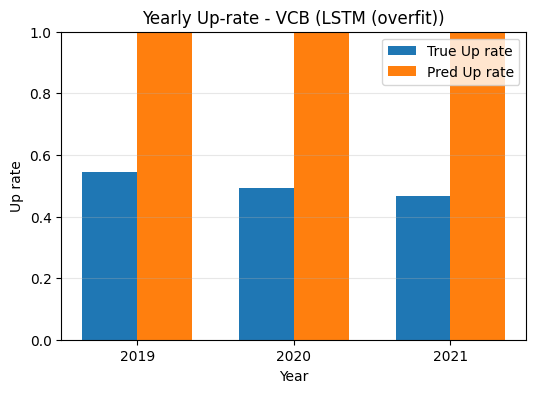

In [28]:
#B22DCCN476 - Đỗ Ngọc Lâm

df_yearly = df_daily_pred.copy()
df_yearly["year"] = pd.to_datetime(df_yearly["date"]).dt.year

yearly_summary = df_yearly.groupby("year").agg(
    true_up_rate = ("y_true", "mean"),
    pred_up_rate = ("y_pred", "mean")
).reset_index()

print("Tỉ lệ ngày Up theo năm (true vs predicted):")
display(yearly_summary)

plt.figure(figsize=(6,4))
x = np.arange(len(yearly_summary))
width = 0.35

plt.bar(x - width/2, yearly_summary["true_up_rate"], width, label="True Up rate")
plt.bar(x + width/2, yearly_summary["pred_up_rate"], width, label="Pred Up rate")
plt.xticks(x, yearly_summary["year"])
plt.ylim(0,1)
plt.ylabel("Up rate")
plt.xlabel("Year")
plt.title(f"Yearly Up-rate - VCB ({best_model_name})")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()
